In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q lightgbm shap

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')
import gc

In [ ]:
TRAIN_SAMPLES = 150000   # ← Increase to 300k+ if your RAM allows
TEST_SAMPLES  = 30000
RANDOM_STATE  = 42

In [ ]:
train_path = "/content/drive/MyDrive/train.csv"
test_path  = "/content/drive/MyDrive/test.csv"

In [ ]:
print("Loading data...")
train_df = pd.read_csv(train_path).sample(TRAIN_SAMPLES, random_state=RANDOM_STATE)
test_df  = pd.read_csv(test_path).sample(TEST_SAMPLES, random_state=RANDOM_STATE)

Loading data...


In [ ]:
train_df = train_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

In [ ]:
all_labels = pd.concat([train_df['label'], test_df['label']]).unique()
le = LabelEncoder()
le.fit(all_labels)

LabelEncoder()

In [ ]:
train_df['label'] = le.transform(train_df['label'])
test_df['label']  = le.transform(test_df['label'])

In [ ]:
print(f"Number of classes: {len(le.classes_)}")
print("Train class distribution (top 10):")
print(pd.Series(le.inverse_transform(train_df['label'])).value_counts().head(10))

Number of classes: 34
Train class distribution (top 10):
DDoS-ICMP_Flood            23156
DDoS-UDP_Flood             17262
DDoS-TCP_Flood             14280
DDoS-PSHACK_Flood          13199
DDoS-SYN_Flood             13137
DDoS-RSTFINFlood           13047
DDoS-SynonymousIP_Flood    11319
DoS-UDP_Flood              10810
DoS-TCP_Flood               8652
DoS-SYN_Flood               6466
Name: count, dtype: int64


In [ ]:
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test  = test_df.drop('label', axis=1)
y_test  = test_df['label']

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
print("\n Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)
rf.fit(X_train_scaled, y_train)


 Training Random Forest...


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [ ]:
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf,
                            labels=range(len(le.classes_)),
                            target_names=le.classes_,
                            digits=4, zero_division=0))

Random Forest Accuracy: 0.9897

Random Forest Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware     0.0000    0.0000    0.0000         2
          BenignTraffic     0.7978    0.9906    0.8838       745
       BrowserHijacking     0.0000    0.0000    0.0000         3
       CommandInjection     0.6667    0.6667    0.6667         3
 DDoS-ACK_Fragmentation     0.9944    0.9833    0.9888       180
        DDoS-HTTP_Flood     1.0000    0.7778    0.8750        18
        DDoS-ICMP_Flood     0.9991    0.9998    0.9995      4597
DDoS-ICMP_Fragmentation     0.9855    0.9891    0.9872       274
      DDoS-PSHACK_Flood     1.0000    0.9992    0.9996      2654
       DDoS-RSTFINFlood     1.0000    0.9988    0.9994      2561
         DDoS-SYN_Flood     0.9993    0.9985    0.9989      2687
         DDoS-SlowLoris     0.7647    0.9286    0.8387        14
DDoS-SynonymousIP_Flood     0.9991    0.9991    0.9991      2348
         DDoS-TCP_Fl

In [ ]:
print("\n Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_model.fit(X_train_scaled, y_train)


 Training LightGBM...


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               n_jobs=-1, random_state=42, verbose=-1)

In [ ]:
y_pred_lgb = lgb_model.predict(X_test_scaled)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

In [ ]:
print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb,
                            labels=range(len(le.classes_)),
                            target_names=le.classes_,
                            digits=4, zero_division=0))

LightGBM Accuracy: 0.9909

LightGBM Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware     0.0000    0.0000    0.0000         2
          BenignTraffic     0.8955    0.9436    0.9190       745
       BrowserHijacking     0.5000    0.3333    0.4000         3
       CommandInjection     0.0000    0.0000    0.0000         3
 DDoS-ACK_Fragmentation     1.0000    1.0000    1.0000       180
        DDoS-HTTP_Flood     1.0000    0.7222    0.8387        18
        DDoS-ICMP_Flood     1.0000    1.0000    1.0000      4597
DDoS-ICMP_Fragmentation     0.9964    1.0000    0.9982       274
      DDoS-PSHACK_Flood     1.0000    0.9989    0.9994      2654
       DDoS-RSTFINFlood     0.9996    1.0000    0.9998      2561
         DDoS-SYN_Flood     0.9996    0.9985    0.9991      2687
         DDoS-SlowLoris     0.8235    1.0000    0.9032        14
DDoS-SynonymousIP_Flood     1.0000    0.9991    0.9996      2348
         DDoS-TCP_Flood     1.

In [ ]:
print("\n Creating Ensemble (Soft Voting)...")
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('lgb', lgb_model)],
    voting='soft',          # uses probabilities → better for imbalance
    weights=[1, 1.5]        # you can tune these (LGB usually stronger)
)

ensemble.fit(X_train_scaled, y_train)


 Creating Ensemble (Soft Voting)...


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('lgb',
                              LGBMClassifier(class_weight='balanced',
                                             learning_rate=0.05,
                                             n_estimators=300, n_jobs=-1,
                                             random_state=42, verbose=-1))],
                 voting='soft', weights=[1, 1.5])

In [ ]:
ensemble.fit(X_train_scaled, y_train)   # fits both again (fast)

y_pred_ens = ensemble.predict(X_test_scaled)
acc_ens = accuracy_score(y_test, y_pred_ens)

In [ ]:
print(f"Ensemble Accuracy: {acc_ens:.4f}")
print("\nEnsemble Classification Report:")
print(classification_report(y_test, y_pred_ens,
                            labels=range(len(le.classes_)),
                            target_names=le.classes_,
                            digits=4, zero_division=0))

Ensemble Accuracy: 0.9913

Ensemble Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware     0.0000    0.0000    0.0000         2
          BenignTraffic     0.8831    0.9530    0.9167       745
       BrowserHijacking     0.5000    0.3333    0.4000         3
       CommandInjection     0.0000    0.0000    0.0000         3
 DDoS-ACK_Fragmentation     1.0000    1.0000    1.0000       180
        DDoS-HTTP_Flood     1.0000    0.7222    0.8387        18
        DDoS-ICMP_Flood     1.0000    1.0000    1.0000      4597
DDoS-ICMP_Fragmentation     0.9964    1.0000    0.9982       274
      DDoS-PSHACK_Flood     1.0000    0.9989    0.9994      2654
       DDoS-RSTFINFlood     0.9996    1.0000    0.9998      2561
         DDoS-SYN_Flood     0.9996    0.9996    0.9996      2687
         DDoS-SlowLoris     0.8235    1.0000    0.9032        14
DDoS-SynonymousIP_Flood     1.0000    0.9996    0.9998      2348
         DDoS-TCP_Flood     0.

In [ ]:
print("\n Generating SHAP explanations (using LightGBM - fastest)...")

# SHAP on a random subset of test set (fast & representative)
sample_idx = np.random.choice(len(X_test_scaled), 1000, replace=False)
X_test_sample = X_test_scaled[sample_idx]
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_sample)


 Generating SHAP explanations (using LightGBM - fastest)...


Global Feature Importance (SHAP Summary Plot):


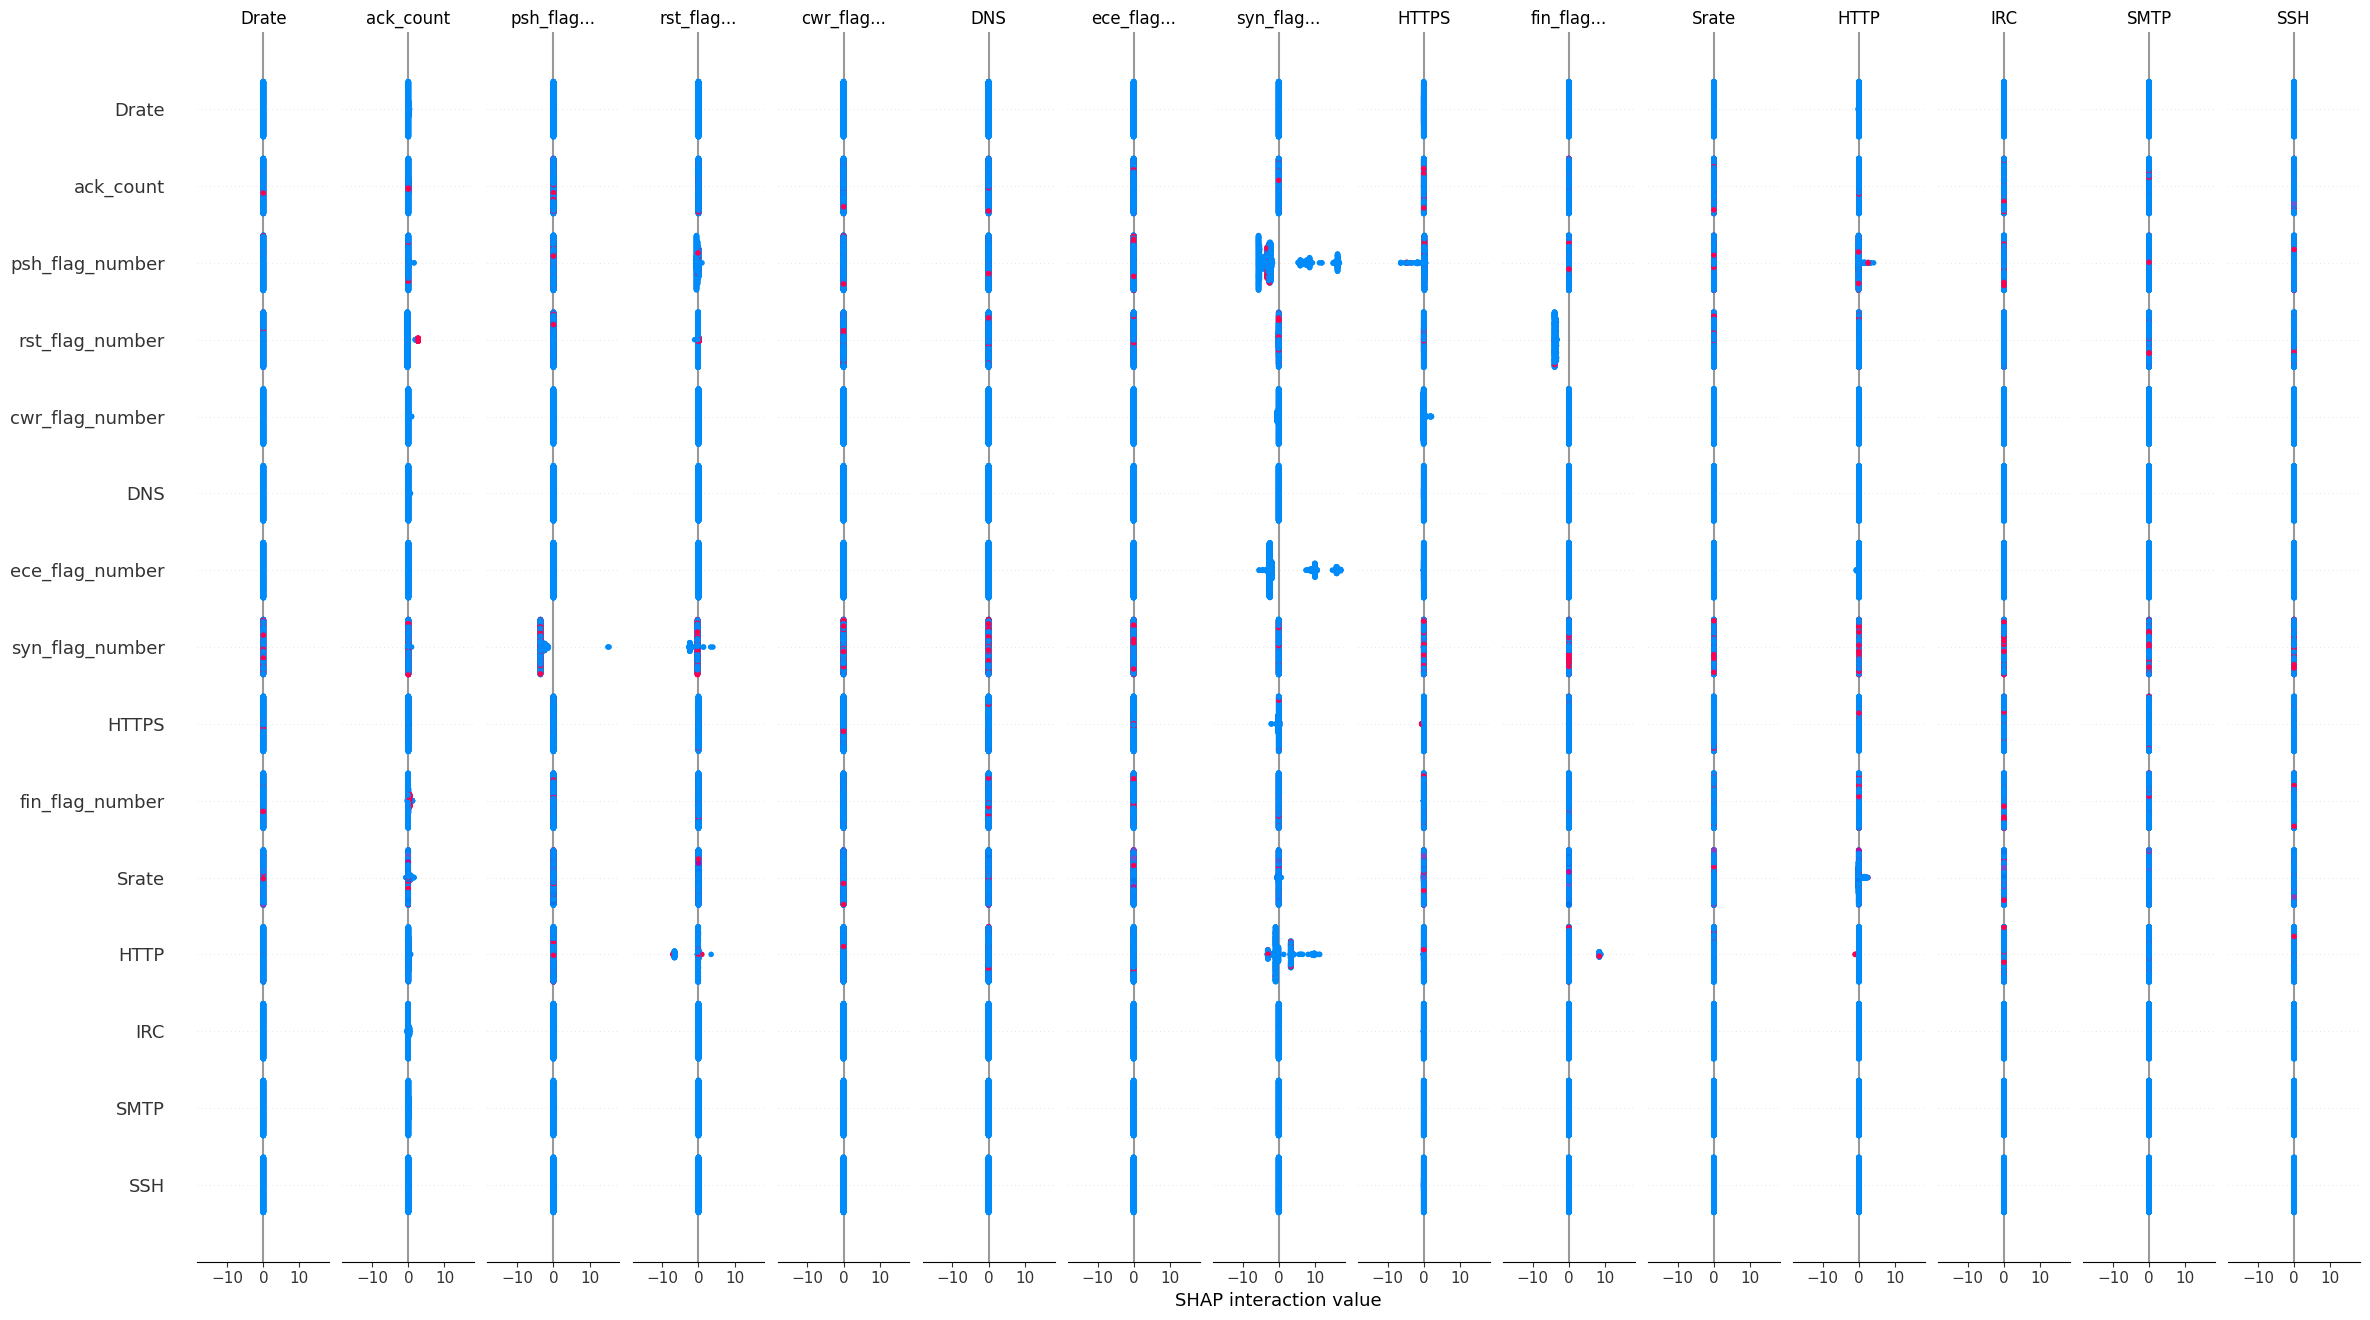

In [ ]:
print("Global Feature Importance (SHAP Summary Plot):")
shap.summary_plot(shap_values, X_test_sample, feature_names=X_train.columns, max_display=15)

In [ ]:
print("\nForce plot for sample #0 (example prediction explanation):")
shap.force_plot(explainer.expected_value[0], shap_values[0][0],
                X_test_sample[0], feature_names=X_train.columns, matplotlib=True)


Force plot for sample #0 (example prediction explanation):


DimensionError: Length of features is not equal to the length of shap_values!

In [ ]:
print("\n🎉 Done! Compare the three accuracies above.")
print("If Ensemble > both individuals → great! Otherwise we can tune weights or try stacking.")


🎉 Done! Compare the three accuracies above.
If Ensemble > both individuals → great! Otherwise we can tune weights or try stacking.
